## **Продвинутые методы обучения регрессионных моделей и работа с несбалансированными данными**

Домашнее задание: полный пайплайн

SGD-регрессия (3 балла)

In [ ]:
# Задача: предсказать длину текста
# 1. Загрузите 20newsgroups с категориями ['rec.sport.hockey', 'sci.space', 'talk.politics.mideast']
# 2. Создайте целевую переменную - количество символов в тексте
# 3. Сделайте TF-IDF векторизацию с max_features=20000
# 4. Обучите SGDRegressor с параметрами:
#    - max_iter=1000
#    - random_state=42
#    - learning_rate='adaptive'
#    - eta0=0.01
# 5. Обучите LinearRegression (если позволяет память) или используйте часть данных
# 6. Сравните:
#    - Время обучения
#    - MSE и MAE
#    - R²

In [126]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import time
from scipy.sparse import hstack
from scipy.sparse import vstack
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

In [68]:
# Загружаем данные
categories = ['rec.sport.hockey', 'sci.space', 'talk.politics.mideast']
newsgroups = fetch_20newsgroups(subset='all',
                                categories=categories,
                                remove=('headers', 'footers', 'quotes'),
                                shuffle=True,
                                random_state=42,
                                n_retries=8,
                                delay=3)

In [3]:
newsgroups.data[:5]

['It\'s all my fault. \nI am in violation of one of my own rules:\n"Avoid FollowingUp to a Barf posting."\n\n\n\n\n\nThose damned, spiking Israelists, right, Barfling?\n\n\n"Trained Seals"?  You mean the ones that flap their flippers making\n"Arf, Arf!  Arf, Arf!" sounds?\n\n\nIn your own diseased mind, you now seem to believe that tax exemption\nis equivalent to government funding.  Holy Shit, Batman!  The US\ngovernment is now one of the major supporters of the Catholic Church\n--  in violation of the rules of separation of Church and State! \n\n\nQuick, Bill!  Commandeer all the churches and give them to the People!\nOr does your anti-logic only apply to the mosques belonging to what\nyou have described as "Ragheads" or perhaps the synagogues of those\nyou have characterized as "Hymies"?\n',
 '\n\nYou missed something.  I think it takes off vertically and is intended\nto land the same way.\n\n-- \n"Insisting on perfect safety is for people who don\'t have the balls to live\n in the 

In [69]:
def clean_text(text):
    normalized = re.sub(r'\s+', ' ', text.strip())
    cleaned = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', normalized)
    return cleaned.strip()

In [70]:
texts = []
for text in newsgroups.data:
  text_fixed = clean_text(text)
  texts.append(text_fixed)

In [71]:
texts[:5]

['It\'s all my fault. I am in violation of one of my own rules: "Avoid FollowingUp to a Barf posting." Those damned, spiking Israelists, right, Barfling? "Trained Seals"? You mean the ones that flap their flippers making "Arf, Arf! Arf, Arf!" sounds? In your own diseased mind, you now seem to believe that tax exemption is equivalent to government funding. Holy Shit, Batman! The US government is now one of the major supporters of the Catholic Church -- in violation of the rules of separation of Church and State! Quick, Bill! Commandeer all the churches and give them to the People! Or does your anti-logic only apply to the mosques belonging to what you have described as "Ragheads" or perhaps the synagogues of those you have characterized as "Hymies"?',
 'You missed something. I think it takes off vertically and is intended to land the same way. -- "Insisting on perfect safety is for people who don\'t have the balls to live in the real world." -- Mary Shafer, NASA Ames Dryden',
 "I've bee

In [7]:
# Создаём целевую переменную - длина текста (регрессия)
y = np.array([len(text) for text in texts])

In [8]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=20000)
X = vectorizer.fit_transform(texts)

In [9]:
# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
reg = SGDRegressor(random_state=42, learning_rate='adaptive')
start_time = time.time()
reg.fit(X_train, y_train)
reg_time = time.time() - start_time

In [11]:
y_pred_reg = reg.predict(X_test)

In [12]:
print(f"MSE: {mse(y_test, y_pred_reg):.0f}")
print(f"MAE: {mae(y_test, y_pred_reg):.0f}")
print(f"R^2: {r2_score(y_test, y_pred_reg):.3f}")
print(f"Время обучения: {reg_time:.2f} сек")

MSE: 5148892
MAE: 1172
R^2: 0.625
Время обучения: 2.30 сек


In [15]:
start_time = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_time = time.time() - start_time

In [16]:
y_pred_lr = lr.predict(X_test)

In [18]:
print(f"MSE: {mse(y_test, y_pred_lr):.0f}")
print(f"MAE: {mae(y_test, y_pred_lr):.0f}")
print(f"R^2: {r2_score(y_test, y_pred_lr):.3f}")
print(f"Время обучения: {lr_time:.2f} сек")

MSE: 7218788
MAE: 1647
R^2: 0.475
Время обучения: 0.77 сек


**Общие выводы:**

- SGDRegressor превосходит LinearRegression по всем метрикам качества, несмотря на более длительное обучение. Выигрыш в точности составляет порядка ~29% по ошибкам (MSE и MAE)

- Модель линейной регрессии объясняет менее половины вариации данных, о чем нам говорит значение параметра R² < 0.5. Это может говорить нам о том, что аналитическая модель хуже справляется с особенностями данных

- SGDRegressor выигрывает, вероятно, за счёт регуляризации, которая помогает бороться с переобучением и нестабильностью коэффициентов, чего лишена модель линейной регрессии

Балансировка классов (4 балла)

In [ ]:
# Задача: классификация категорий с дисбалансом
# 1. Создайте несбалансированный датасет:
#    - Хоккей: 600 текстов
#    - Космос: 60 текстов (в 10 раз меньше)
# 2. Векторизуйте тексты (CountVectorizer, max_features=3000)
# 3. Разделите на train/test (stratify!)
# 4. Обучите 4 модели с разными стратегиями:
#    a) Без балансировки
#    b) С oversampling (повторением)
#    c) С undersampling
#    d) С весами классов (class_weight='balanced')
# 5. Для каждой модели выведите:
#    - classification_report
#    - confusion_matrix (визуализация)
# 6. Сделайте вывод: какая стратегия лучше для редкого класса?

### Ваш код здесь ###

In [72]:
# Создаём искусственный дисбаланс
# Оставляем все тексты про хоккей, берём только 10% текстов про космос
hockey_idx = [i for i, label in enumerate(newsgroups.target) if label == 0]
space_idx = [i for i, label in enumerate(newsgroups.target) if label == 1]

In [73]:
hockey_texts = [texts[i] for i in hockey_idx]
space_texts = [texts[i] for i in space_idx]

In [74]:
# Искусственно уменьшаем класс космоса и хоккея до 60 и 600 соответсвенно
np.random.seed(42)
space_small_idx = np.random.choice(len(space_texts), size=60, replace=False)
space_texts_small = [space_texts[i] for i in space_small_idx]

hockey_small_idx = np.random.choice(len(hockey_texts), size=600, replace=False)
hockey_texts_small = [hockey_texts[i] for i in hockey_small_idx]

print(f'Теперь количество текстов про хоккей {len(hockey_texts_small)}, а про космос {len(space_texts_small)}')

Теперь количество текстов про хоккей 600, а про космос 60


In [75]:
# Собираем несбалансированный датасет
texts_imbalanced = list(hockey_texts_small) + list(space_texts_small)
y_imbalanced = [0] * len(hockey_texts_small) + [1] * len(space_texts_small)

print(f"Размер датасета: {len(texts_imbalanced)}")
print(f"Хоккей: {len(hockey_texts_small)}")
print(f"Космос: {len(space_texts_small)}")

Размер датасета: 660
Хоккей: 600
Космос: 60


In [76]:
# Векторизация
vectorizer = CountVectorizer(stop_words='english', max_features=3000)
X_imb = vectorizer.fit_transform(texts_imbalanced)

In [77]:
# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

In [78]:
# Базовая модель
lr_base = LogisticRegression()
lr_base.fit(X_train, y_train)

In [79]:
y_pred_base = lr_base.predict(X_test)

In [80]:
print(classification_report(y_test, y_pred_base, target_names=['hockey', 'space']))

              precision    recall  f1-score   support

      hockey       0.95      1.00      0.98       120
       space       1.00      0.50      0.67        12

    accuracy                           0.95       132
   macro avg       0.98      0.75      0.82       132
weighted avg       0.96      0.95      0.95       132



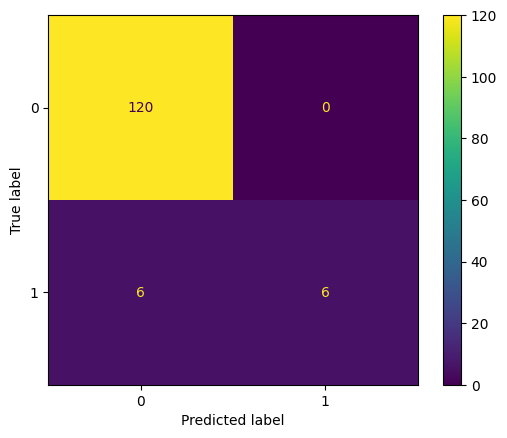

In [87]:
ConfusionMatrixDisplay.from_estimator(lr_base, X_test, y_test)

Вывод: абсолютно верно определены все представители бОльшего класса, а вот примеры из минорного класса распределились пополам (6 примерам был присвоен нужный класс, а вот 6 остальных пролетели мимо)

**Oversampling**

In [90]:
hockey_idx = [i for i, label in enumerate(y_train) if label == 0]
space_idx = [i for i, label in enumerate(y_train) if label == 1]

X_train_hockey = [texts[i] for i in hockey_idx]
X_train_space = [texts[i] for i in space_idx]

# 1. Явно преобразуем в numpy массивы
X_train_hockey_dense = vectorizer.transform(X_train_hockey)
X_train_space_dense = vectorizer.transform(X_train_space)

print(f"Хоккей: {X_train_hockey_dense.shape}")
print(f"Космос: {X_train_space_dense.shape}")

Хоккей: (480, 3000)
Космос: (48, 3000)


In [95]:
# 2. Ресэмплим
X_train_space_oversampled = resample(
    X_train_space_dense,
    replace=True,
    n_samples=X_train_hockey_dense.shape[0],
    random_state=42
)

In [104]:
# 3. Объединяем
X_train_balanced = vstack([X_train_hockey_dense, X_train_space_oversampled])
y_train_balanced = np.hstack([
    np.zeros(X_train_hockey_dense.shape[0]),
    np.ones(X_train_space_oversampled.shape[0])
])

In [106]:
# 4. Обучаем
lr_balanced = LogisticRegression()
lr_balanced.fit(X_train_balanced, y_train_balanced)

LogisticRegression()

In [111]:
y_pred_balanced = lr_balanced.predict(X_test)

In [108]:
print("\nПосле oversampling")
print(classification_report(y_test, y_pred_balanced, target_names=['hockey', 'space']))


После oversampling
              precision    recall  f1-score   support

      hockey       0.91      0.95      0.93       120
       space       0.14      0.08      0.11        12

    accuracy                           0.87       132
   macro avg       0.53      0.52      0.52       132
weighted avg       0.84      0.87      0.86       132



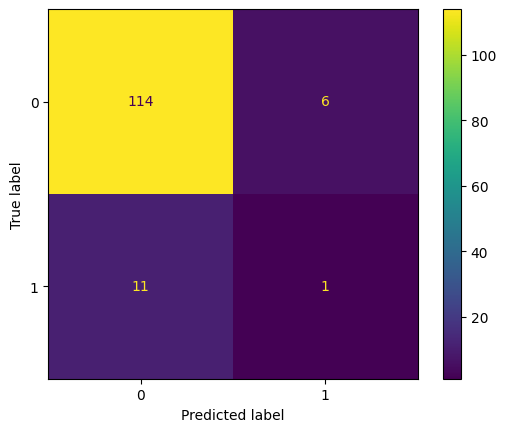

In [110]:
ConfusionMatrixDisplay.from_estimator(lr_balanced, X_test, y_test)

**Вывод:** при искусственном заполнении минорного класса примерами пострадал не только он сам, но и класс, изначально представленный бОльшим кол-вом примеров.

**Undersampling**

In [114]:
# Уменьшаем частый класс (хоккей)
hockey_texts_undersampled = resample(
    X_train_hockey_dense,
    replace=False,
    n_samples=X_train_space_dense.shape[0],
    random_state=42
)

X_train_undersampled = vstack([hockey_texts_undersampled, X_train_space_dense])
y_train_undersampled = np.hstack([
    np.zeros(hockey_texts_undersampled.shape[0]),
    np.ones(X_train_space_dense.shape[0])
])

In [115]:
lr_undersampled = LogisticRegression()
lr_undersampled.fit(X_train_undersampled, y_train_undersampled)

LogisticRegression()

In [116]:
y_pred_undersampled = lr_undersampled.predict(X_test)

print("\nПосле undersampling")
print(classification_report(y_test, y_pred_undersampled, target_names=['hockey', 'space']))


После undersampling
              precision    recall  f1-score   support

      hockey       0.90      0.43      0.58       120
       space       0.08      0.50      0.14        12

    accuracy                           0.44       132
   macro avg       0.49      0.47      0.36       132
weighted avg       0.82      0.44      0.54       132



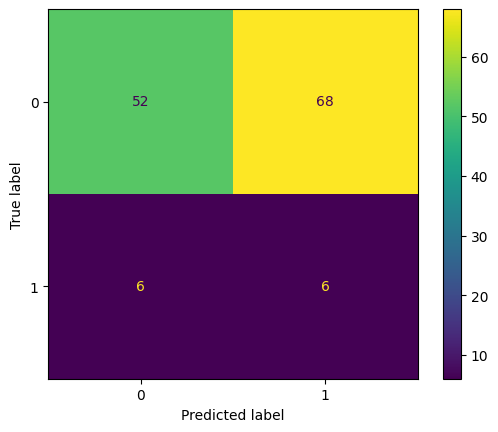

In [117]:
ConfusionMatrixDisplay.from_estimator(lr_undersampled, X_test, y_test)

**Вывод:** ситуауия для минорного класса стабилизировалась, чего нельзя сказать о классе текстов о хоккее. Так как в обучающей выборке их стало гораздо меньше, модель не смогла уловить значимые различия между классами, как следствие - возможное недообучение.

**Weighted**

In [120]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), weights))

In [121]:
lr_weighted = LogisticRegression(class_weight=class_weight_dict)
lr_weighted.fit(X_train, y_train)

LogisticRegression(class_weight={np.int64(0): np.float64(0.55),
                                 np.int64(1): np.float64(5.5)})

In [122]:
y_pred_weighted = lr_weighted.predict(X_test)

In [123]:
print("\nС весами классов")
print(classification_report(y_test, y_pred_weighted, target_names=['hockey', 'space']))


С весами классов
              precision    recall  f1-score   support

      hockey       0.97      0.95      0.96       120
       space       0.60      0.75      0.67        12

    accuracy                           0.93       132
   macro avg       0.79      0.85      0.81       132
weighted avg       0.94      0.93      0.94       132



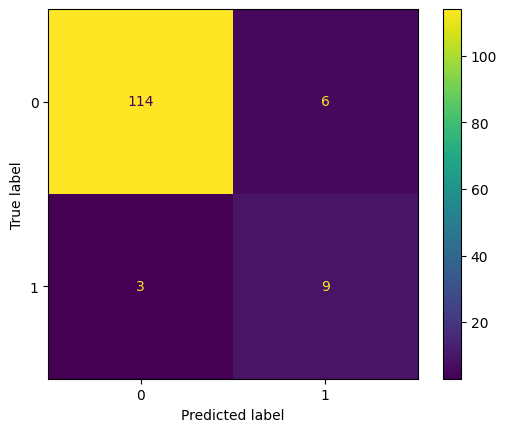

In [124]:
ConfusionMatrixDisplay.from_estimator(lr_weighted, X_test, y_test)

**Вывод:** на мой взгляд - самая удачная модель из 4. Есть ошибки в обоих классах, но тем не менее минорный класс стал определяться лучше (75% объктов был присвоен верный класс вместо 50% изначальных)

Feature engineering (1 балл)

In [ ]:
# Задача: улучшить модель через создание признаков
# 1. Возьмите сбалансированные данные из Части 2 (лучший метод)
# 2. Используйте TF-IDF для веткоризации
# 3. Сравните качество до и после добавления признаков

### Ваш код здесь ###

In [128]:

# 1. Базовые текстовые признаки
# TF-IDF векторизация
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(texts_imbalanced)

# 2. Создаём дополнительные признаки
additional_features = []

for text in texts_imbalanced:
    features = []
    # Длина текста
    features.append(len(text))
    # Количество заглавных букв
    features.append(sum(1 for c in text if c.isupper()))
    # Количество восклицательных знаков
    features.append(text.count('!'))
    # Количество вопросительных знаков
    features.append(text.count('?'))
    # Есть ли ссылка
    features.append(1 if 'http' in text or 'www' in text else 0)

    additional_features.append(features)

X_extra = np.array(additional_features)

# Нормализуем дополнительные признаки
scaler = StandardScaler()
X_extra_scaled = scaler.fit_transform(X_extra)

# Объединяем с текстовыми признаками
X_combined = hstack([X_tfidf, X_extra_scaled])

In [129]:
# Разделяем и обучаем
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

In [130]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), weights))

In [131]:
lr_combined = LogisticRegression(class_weight=class_weight_dict)
lr_combined.fit(X_train, y_train)

LogisticRegression(class_weight={np.int64(0): np.float64(0.55),
                                 np.int64(1): np.float64(5.5)})

In [132]:
y_pred_combined = lr_combined.predict(X_test)

In [133]:
print("С дополнительными признаками")
print(classification_report(y_test, y_pred_combined, target_names=['hockey', 'space']))

С дополнительными признаками
              precision    recall  f1-score   support

      hockey       0.98      1.00      0.99       120
       space       1.00      0.75      0.86        12

    accuracy                           0.98       132
   macro avg       0.99      0.88      0.92       132
weighted avg       0.98      0.98      0.98       132



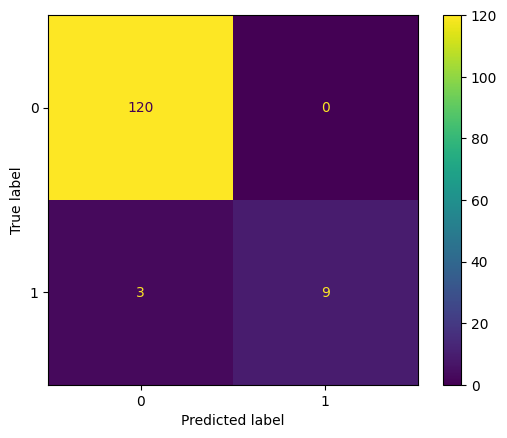

In [134]:
ConfusionMatrixDisplay.from_estimator(lr_combined, X_test, y_test)

**Вывод:** самая идеальная модель - все объекты крупного класса получили верную метку, для минорного класса сохранился самый положительный результат распределения.